In [1]:
#Algorithm - Seasonal Autoregressive Integrated Moving Average - (SARIMA)

In [2]:
#1.IMPORTING PANDAS LIBRARY

import pandas as pd
# import → Python keyword used to bring in a library/module
# pandas → open-source library for data manipulation and analysis
# as → keyword used to assign an alias (short name)
# pd → alias used to refer to pandas throughout the code

# Summary: This line imports the pandas library and gives it the shorter name "pd" for easy use later in the notebook.

In [3]:
#https://machinelearningmastery.com/time-series-forecasting-methods-in-python-cheat-sheet/

In [4]:
#2.IMPORTING NSEPY AND DATETIME LIBRARIES

from nsepy import get_history as gh
# from → keyword used to import a specific part of a module
# nsepy → library used to fetch historical stock data from NSE (India)
# import → keyword used to bring in a library/module/function
# get_history → function used to fetch historical stock price data
# as → keyword used to assign an alias (short name)
# gh → alias used to refer to get_history function

import datetime as dt
# import → keyword used to bring in a library/module
# datetime → built-in module used to work with dates and times
# as → keyword used to assign an alias (short name)
# dt → alias used to refer to datetime module

# Summary: This line imports the get_history function from nsepy (renamed as gh) to fetch stock data, and the datetime module (renamed as dt) 
# to handle date values.

In [8]:
# UPGRADING YFINANCE TO LATEST VERSION

#!pip install yfinance --upgrade --no-cache-dir

# !pip install → command to install/upgrade a Python package
# yfinance → the library being upgraded
# --upgrade → ensures the latest version is installed
# --no-cache-dir → avoids using a cached (possibly broken) older version

# Summary: This upgrades yfinance to its latest version, which often resolves "possibly delisted" errors caused by outdated API handling.

In [10]:
import yfinance as yf
print(yf.__version__)

1.7.0


In [13]:
#3.FETCHING STOCK DATA USING YFINANCE

import yfinance as yf
# import → keyword used to bring in a library/module
# yfinance → library used to fetch stock market data from Yahoo Finance
# as → keyword used to assign an alias (short name)
# yf → alias used to refer to yfinance library

stk_data = yf.download("ETERNAL.NS", start='2022-01-01', end='2022-02-08')
# stk_data → variable to store the fetched stock data
# yf.download → function used to download historical stock data
# "ETERNAL.NS" → new NSE ticker for the company formerly known as Zomato (renamed April 2025)
# start → parameter specifying the start date (as string 'YYYY-MM-DD')
# end → parameter specifying the end date (as string 'YYYY-MM-DD')

# Summary: This fetches historical stock data using the correct current ticker (ETERNAL.NS), since Zomato's symbol was retired after its 
# 2025 rename to Eternal Ltd.

[*********************100%***********************]  1 of 1 completed


In [14]:
#4.SELECTING REQUIRED COLUMNS FROM STOCK DATA

stk_data = stk_data[["Open","High","Low","Close"]]
# stk_data → variable holding the stock data DataFrame
# [["Open","High","Low","Close"]] → selects only these specific columns from the DataFrame
# "Open" → opening price of the stock for each day
# "High" → highest price of the stock for each day
# "Low" → lowest price of the stock for each day
# "Close" → closing price of the stock for each day

# Summary: This line filters stk_data to keep only the Open, High, Low, and Close columns.

In [15]:
#5.DISPLAYING STOCK DATA

stk_data
# stk_data → variable holding the filtered stock data (Open, High, Low, Close columns)

# Summary: This line displays the contents of stk_data to preview the fetched and filtered stock data.

Price,Open,High,Low,Close
Ticker,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS
Date,,,,
2022-01-03,139.699997,142.449997,138.300003,141.350006
2022-01-04,141.350006,141.550003,137.600006,138.350006
2022-01-05,137.899994,137.899994,133.300003,133.949997
2022-01-06,133.000000,133.149994,129.600006,130.000000
2022-01-07,130.000000,131.449997,129.000000,129.250000
2022-01-10,130.500000,130.899994,129.399994,130.199997
2022-01-11,131.000000,132.500000,130.000000,131.300003
2022-01-12,132.100006,132.899994,131.600006,132.250000


In [16]:
#6.SCALING THE TARGET COLUMN USING MINMAXSCALER

from sklearn.preprocessing import MinMaxScaler
# from → keyword used to import a specific part of a module
# sklearn.preprocessing → module containing data preprocessing tools
# import → keyword used to bring in a library/module/function
# MinMaxScaler → class used to scale features to a fixed range (default 0 to 1)

Ms = MinMaxScaler()
# Ms → variable to store the MinMaxScaler object
# MinMaxScaler() → creates an instance of the scaler

data1 = Ms.fit_transform(stk_data[["Close"]])
# data1 → variable to store the scaled data
# Ms.fit_transform → function that fits the scaler to the data and transforms it
# stk_data[["Close"]] → selects the "Close" column as a DataFrame

print("Len:", data1.shape)
# print → built-in function to display output
# "Len:" → label text for the printed output
# data1.shape → returns the dimensions (rows, columns) of the scaled data

# Summary: This line scales the "Close" column values between 0 and 1 using MinMaxScaler and prints the shape of the resulting scaled data.

Len: (25, 1)


In [17]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))#Autoregressive Integrated Moving Average (ARIMA)\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [18]:
#7.TRAINING SARIMAX MODEL WITH DIFFERENT ORDER COMBINATIONS

orders = [(0,0,0),(0,0,1),(2,0,1),(1,1,1)]
# orders → variable storing a list of SARIMAX order combinations to test
# (p,d,q) → p=autoregressive terms, d=differencing, q=moving average terms

#orderslist=[]
# orderslist → commented-out empty list (currently unused, likely meant to store tested orders)

#rscorelist=[]
# rscorelist → commented-out empty list (currently unused, likely meant to store R-squared scores)

for i in orders:
# for → keyword used to start a loop
# i → loop variable representing each order tuple
# in orders → iterates through the orders list

    #orderslist.append(i)
    # orderslist.append(i) → commented-out line that would store the current order

    from statsmodels.tsa.statespace.sarimax import SARIMAX
    # from → keyword used to import a specific part of a module
    # statsmodels.tsa.statespace.sarimax → module containing SARIMAX modeling tools
    # SARIMAX → class used to build Seasonal AutoRegressive Integrated Moving Average with eXogenous factors models

    model = SARIMAX(data1, order=i, seasonal_order=(0,0,0,12))
    # model → variable to store the SARIMAX model object
    # SARIMAX → class used to create the model
    # data1 → scaled data used to fit the model
    # order=i → current non-seasonal ARIMA order from the loop iteration
    # seasonal_order=(0,0,0,12) → seasonal component (P=0, D=0, Q=0, seasonal period=12)

    model_fit = model.fit()
    # model_fit → variable to store the fitted model
    # model.fit() → function that trains the SARIMAX model on data1

    # make prediction
    y_pred = model_fit.predict(0, len(data1)-1)
    # y_pred → variable to store predicted values
    # model_fit.predict → function used to generate predictions
    # 0 → starting index for prediction (beginning of dataset)
    # len(data1)-1 → ending index for prediction (end of dataset)

    #print(y_pred)
    # print(y_pred) → commented-out line to display predicted values

    from stockFunctions import rmsemape
    # from → keyword used to import a specific part of a module
    # stockFunctions → custom user-defined module
    # rmsemape → custom function used to calculate RMSE and MAPE

    rmsemape(data1, y_pred)
    # rmsemape → calls the custom function to print RMSE and MAPE
    # data1 → actual scaled values
    # y_pred → predicted values

# Summary: This loop trains a SARIMAX model on data1 for each order combination in the list (with a fixed seasonal component), 
# predicts values across the full dataset, and prints the RMSE/MAPE performance metrics for comparison.

C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_param

RMSE-Testset: 0.6335663472885011
maPe-Testset: 0.96
RMSE-Testset: 0.39767222970397503
maPe-Testset: 39692693177703.32
RMSE-Testset: 0.23090395565096677
maPe-Testset: 2817668349959.3955
RMSE-Testset: 0.2313548785876174
maPe-Testset: 3388363043103.426


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


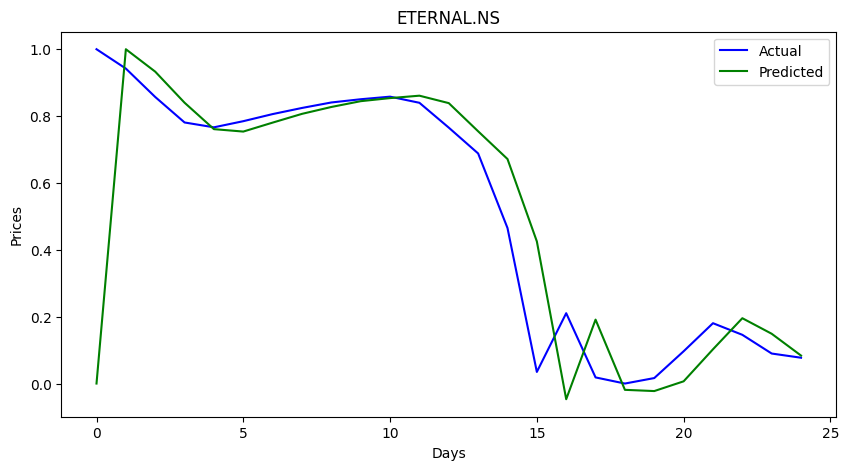

In [19]:
#8.PLOTTING ACTUAL VS PREDICTED VALUES

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(data1, y_pred, "Actual", "Predicted", "ETERNAL.NS", "Days", "Prices")
# graph → function call to generate the plot
# data1 → actual scaled values to plot
# y_pred → predicted values to plot
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "ETERNAL.NS" → title of the graph
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices using the custom graph function, labeled with title and axis names.

In [20]:
#9.CHECKING LENGTH OF SCALED DATA

len(data1)
# len → built-in function used to return the number of items in an object
# data1 → variable holding the scaled "Close" price values

# Summary: This line checks and returns the total number of rows in the scaled dataset data1.

25

In [21]:
#10.CONVERTING ACTUAL DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

aTestNormTable = conversionSingle(data1, ["Close"])
# aTestNormTable → variable to store the converted normalized table
# conversionSingle → function call to reshape data1 into table format
# data1 → scaled actual values
# ["Close"] → column name list used as header

actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
# actual_stock_price_test_ori → variable to store the original-scale stock prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# aTestNormTable → normalized table to be converted back to original values

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, ["Close"])
# actual_stock_price_test_oriA → variable to store the final formatted original-scale prices
# conversionSingle → function call to reshape the data into table format again
# actual_stock_price_test_ori → original-scale stock price values
# ["Close"] → column name list used as header

# Summary: This block converts the normalized actual values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

In [22]:
#11.CONVERTING PREDICTED DATA BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

pTestNormTable = conversionSingle(y_pred, ["Close"])
# pTestNormTable → variable to store the converted normalized prediction table
# conversionSingle → function call to reshape y_pred into table format
# y_pred → normalized predicted values
# ["Close"] → column name list used as header

predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
# predicted_stock_price_test_ori → variable to store the original-scale predicted prices
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# pTestNormTable → normalized table to be converted back to original values

predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, ["Close"])
# predicted_stock_price_test_oriP → variable to store the final formatted original-scale predictions
# conversionSingle → function call to reshape the data into table format again
# predicted_stock_price_test_ori → original-scale predicted price values
# ["Close"] → column name list used as header

# Summary: This block converts the normalized predicted values back to their original price scale using inverse_transform, 
# then reformats them into a table using conversionSingle.

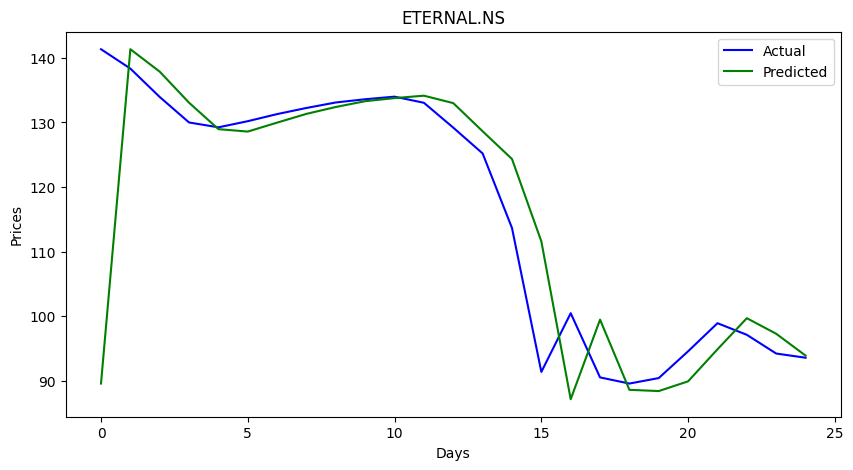

In [23]:
#12.PLOTTING ACTUAL VS PREDICTED VALUES (ORIGINAL SCALE)

from stockFunctions import graph
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# graph → custom function used to plot actual vs predicted values

graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP, "Actual", "Predicted", "ETERNAL.NS", "Days", "Prices")
# graph → function call to generate the plot
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale
# "Actual" → label for the actual values line
# "Predicted" → label for the predicted values line
# "ETERNAL.NS" → title of the graph
# "Days" → label for the x-axis
# "Prices" → label for the y-axis

# Summary: This line plots a graph comparing actual vs predicted stock prices in their original (unscaled) price values using the 
# custom graph function.

In [24]:
#13.CALCULATING RMSE AND MAPE (ORIGINAL SCALE)

from stockFunctions import rmsemape
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# rmsemape → custom function used to calculate RMSE and MAPE

rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)
# rmsemape → function call to compute and print error metrics
# actual_stock_price_test_oriA → actual stock prices in original scale
# predicted_stock_price_test_oriP → predicted stock prices in original scale

# Summary: This line calculates and prints the RMSE and MAPE between actual and predicted stock prices in their original (unscaled) values.

RMSE-Testset: 11.984183416877643
maPe-Testset: 0.051186839908695


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [25]:
#14.FORECASTING NEXT VALUE

forecast = model_fit.predict(len(data1), len(data1)+1)
# forecast → variable to store the forecasted value(s)
# model_fit.predict → function used to generate predictions from the fitted model
# len(data1) → starting index for forecast (one step beyond available data)
# len(data1)+1 → ending index for forecast (1 step beyond starting point)

# Summary: This line uses the fitted SARIMAX model to forecast the next value immediately following the available dataset.

In [26]:
#15.DISPLAYING FORECASTED VALUE

forecast
# forecast → variable holding the forecasted value(s) from the SARIMAX model

# Summary: This line displays the forecasted value generated by the SARIMAX model.

array([0.07217831, 0.06877043])

In [27]:
#16.CONVERTING FORECASTED VALUE BACK TO ORIGINAL SCALE

from stockFunctions import conversionSingle
# from → keyword used to import a specific part of a module
# stockFunctions → custom user-defined module
# conversionSingle → custom function used to convert data into a specific table format

fTestNormTable = conversionSingle(forecast, ["Closefore"])
# fTestNormTable → variable to store the converted normalized forecast table
# conversionSingle → function call to reshape forecast into table format
# forecast → normalized forecasted value(s)
# ["Closefore"] → column name list used as header for the forecast

forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
# forecast_stock_price_test_ori → variable to store the original-scale forecasted price
# Ms.inverse_transform → function used to reverse the MinMaxScaler scaling
# fTestNormTable → normalized table to be converted back to original values

forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])
# forecast_stock_price_test_oriF → variable to store the final formatted original-scale forecast
# conversionSingle → function call to reshape the data into table format again
# forecast_stock_price_test_ori → original-scale forecasted price value(s)
# ["Closefore"] → column name list used as header for the forecast

# Summary: This block converts the normalized forecasted value back to its original price scale using inverse_transform, 
# then reformats it into a table using conversionSingle.

In [28]:
#17.SAVING FORECASTED PRICE TO CSV

forecast_stock_price_test_oriF.to_csv("Closets.csv", index=False)
# forecast_stock_price_test_oriF → variable holding the forecasted stock price (original scale)
# .to_csv → function used to export a DataFrame to a CSV file
# "Closets.csv" → filename for the exported CSV file
# index=False → excludes the DataFrame index from being written to the file

# Summary: This line saves the forecasted stock price to a CSV file named "Closets.csv", without including the row index.

In [29]:
#18.DISPLAYING FORECASTED PRICE (ORIGINAL SCALE)

forecast_stock_price_test_oriF
# forecast_stock_price_test_oriF → variable holding the forecasted stock price converted back to its original scale

# Summary: This line displays the forecasted stock price after converting it back to its original (unscaled) value.

,Closefore
0,93.28884
1,93.112312


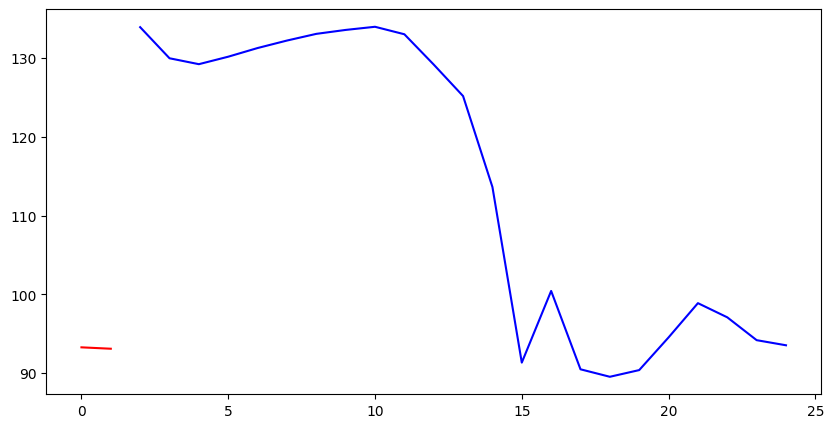

In [30]:
#19.PLOTTING ACTUAL VS FORECASTED VALUES

import matplotlib.pyplot as plt
# import → keyword used to bring in a library/module
# matplotlib.pyplot → module used for creating plots and visualizations
# as → keyword used to assign an alias (short name)
# plt → alias used to refer to matplotlib.pyplot

plt.figure(figsize=(10,5))
# plt.figure → function used to create a new figure for plotting
# figsize=(10,5) → sets the figure size to 10 inches wide and 5 inches tall

plt.plot(actual_stock_price_test_oriA[2:2225], color='blue', label="Actual")
# plt.plot → function used to draw a line plot
# actual_stock_price_test_oriA[2:2225] → actual stock prices, sliced from index 2 to 2225
# color='blue' → sets the line color to blue
# label="Actual" → sets the legend label for this line

plt.plot(forecast_stock_price_test_oriF, color='red', label="Predicted")
# plt.plot → function used to draw a line plot
# forecast_stock_price_test_oriF → forecasted stock prices (original scale)
# color='red' → sets the line color to red
# label="Predicted" → sets the legend label for this line

# Summary: This block plots the actual stock prices in blue and the forecasted stock prices in red on the same graph for visual comparison.